In [1]:
import re
from collections import defaultdict
import numpy as np
import matplotlib.gridspec as gridspec
# import torch as th

K = 8
N = 360
latencies = [[], [], [], [], []]
pattern = re.compile(r'Server receives (\d+) PHASE2BMESSAGE: (\d+), Endpoint: hostname: "(.*?)"\nport: (\d+)')
pattern_start = re.compile(r'Broadcast Start at (\d+), Endpoint: hostname: "(.*?)"\nport: (\d+)')
filename = [
			# 'test=1_gossip=1_numtest=5_N=360.log',
			'test=1_gossip=1_numtest=5_N=360.bk.log',
			'test=1_gossip=2_numtest=5_N=360.log',
			'test=1_gossip=3_numtest=5_N=360.log',
			'test=1_gossip=4_numtest=5_N=360.log',
    'test=1_gossip=0_numtest=5_N=360.log',
			# 'N=1000_random.txt',
			# 'N=1000_random1.txt',
   #          'N=1000_6DGRO.txt',
   #          'N=1000_NN.txt',
   #          'N=1000_NN+1DGRO.txt'
			
			 ]
	
# for K in [3, 5, 10]:
# for K in [3]:
	# filename = [f"test_data/N={N}_1/random_K={K}.txt", f"test_data/N={N}_1/1shortest_K={K}.txt"]
for id in range(len(filename)):
	with open(filename[id]) as f:
		lines = f.readlines()
		lineSize = len(lines)
		# lines = f.
		
	baseport = -1
	time_by_endpoint = [defaultdict(list) for _ in range(5)]
	start_times = [0 for _ in range(5)]
	for i, line in enumerate(lines):
		if 'Borderline' in line or i == lineSize - 1:
			if baseport != -1:
				for braodcaster_port in range(5):
					for endpoint, times in time_by_endpoint[braodcaster_port].items():
						latency = times[0] - start_times[braodcaster_port]
						if endpoint.split(':')[0] == "10.135.2.2":
							latency += 900
							continue
						latencies[id].append(latency)
					# if latency < 0:
					# 	print(filename[id], endpoint, baseport, latency)
					# 	print(times)
                    # 	print(time_by_endpoint[f'127.0.0.7:{baseport}'])
						# assert 0
			if i == lineSize - 1:
				break
			baseport = -1
			time_by_endpoint = [defaultdict(list) for _ in range(5)]
			start_times = [0 for _ in range(5)]
		match = re.match(pattern, line + lines[i + 1])
		if match:
			broadcaster, time, hostname, port = match.groups()
			endpoint = f"{hostname}:{port}"
			time_by_endpoint[int(broadcaster) - 1234][endpoint].append(int(time))
			# print(endpoint, time)
		match = re.match(pattern_start, line + lines[i + 1])
		if match:
			start_time, hostname, port = match.groups()
			start_time = int(start_time)
			baseport = int(port)
			start_times[baseport - 1234] = start_time
			print(start_time, hostname, port)
            # print(start_time, hostname, port)
            # print(start_time, hostname, port)
			# endpoint = f"{hostname}:{port}"
			# time_by_endpoint[endpoint].append(int(time))

1738843420249 10.141.132.2 1234
1738843442073 10.143.10.2 1235
1738843461044 10.135.135.2 1236
1738843481070 10.139.132.2 1237
1738843500838 10.147.6.2 1238
1738842245869 10.141.132.2 1234
1738842267803 10.143.10.2 1235
1738842286738 10.135.135.2 1236
1738842306680 10.139.132.2 1237
1738842326463 10.147.6.2 1238
1738842647308 10.141.132.2 1234
1738842669171 10.143.10.2 1235
1738842688076 10.135.135.2 1236
1738842708002 10.139.132.2 1237
1738842728219 10.147.6.2 1238
1738843061776 10.141.132.2 1234
1738843083554 10.143.10.2 1235
1738843102529 10.135.135.2 1236
1738843122952 10.139.132.2 1237
1738843142674 10.147.6.2 1238
1738840310706 10.141.132.2 1234
1738840322236 10.143.10.2 1235
1738840331747 10.135.135.2 1236
1738840341444 10.139.132.2 1237
1738840351056 10.147.6.2 1238


RAPID [1334, 1339, 1343, 1356, 1369, 1370, 1405, 1440, 1455, 1494]
Chord [1189, 1191, 1197, 1204, 1205, 1212, 1235, 1257, 1292, 1360]
Nearest Neighbour [1130, 1150, 1172, 1190, 1194, 1206, 1215, 1243, 1286, 1342]
Nearest Neighbour + DGRO [978, 982, 1001, 1010, 1055, 1080, 1132, 1189, 1254, 1969]
DGRO [889, 894, 896, 897, 925, 930, 933, 934, 934, 984]


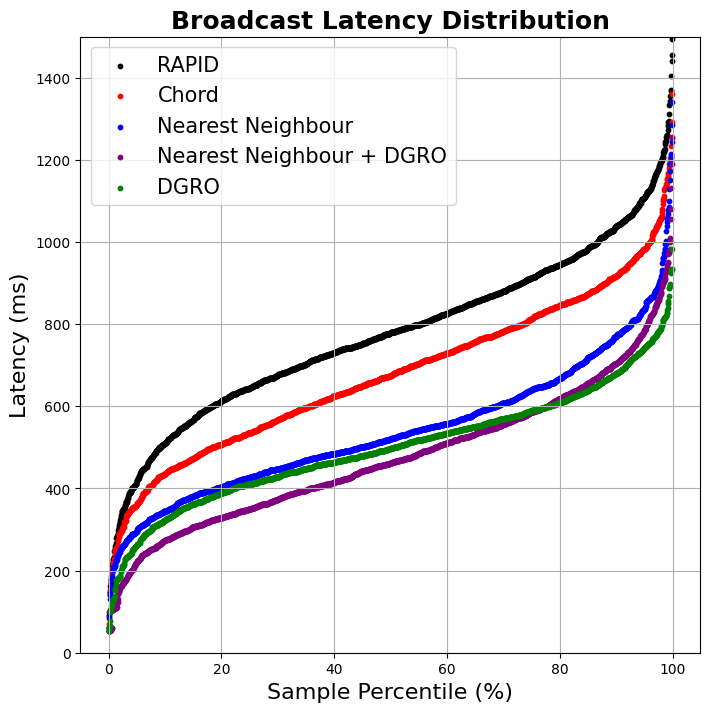

In [24]:
      

import matplotlib.pyplot as plt

# Plot the sorted list

labels = [
    'RAPID','Chord','Nearest Neighbour', 'Nearest Neighbour + DGRO','DGRO'

			  ]
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 8))
# 创建一个 2×5 的 subplot 结构
# fig = plt.figure(figsize=(8, 8))
# gs = gridspec.GridSpec(2, 1 + len(labels), figure=fig)  # 2 行 5 列

# 最左侧的图，占据两行
# ax0 = fig.add_subplot(gs[:, 0])  # `:` 表示合并第 0 列的两行

# 其余 2x4 的图
# axes = []
# for row in range(2):
#     for col in range(1, 1 + len(labels)):  # 从第 1 列开始
#         ax = fig.add_subplot(gs[row, col])
#         axes.append(ax)
colors = ['k', 'r', 'b', 'purple', 'g']
linestyles = ['-', '--', '-.']
cnt = 0
# for k in [3, 5, 10]:
num_bins = 40
shared_bins = np.linspace(0, 1500, num_bins + 1)

for k in [8]:
	for i in range(len(filename)):
		# print(len(latencies[i]))
		path_latency_sorted = sorted(latencies[i])
		# print(path_latency_sorted[:5])
		print(labels[i], path_latency_sorted[-10:])
		# print(path_latency_sorted[:5], path_latency_sorted[-5:])x = [i / len(path_latency_sorted) for i in range(len(path_latency_sorted)]
		x = [j / len(path_latency_sorted) * 100 for j in range(len(path_latency_sorted))]
		# ax[0, 0].scatter(x, path_latency_sorted, linestyle=linestyles[0], s=10,
		ax.scatter(x, path_latency_sorted, linestyle=linestyles[0], s=10,
		  # label=labels[i]+f'_FanOut={k}_N={N}',
		  label=labels[i],
		#label=filename[i],
		    color=colors[i])

		# cnt += 1
# ax[0, 0].set_title('Latency Distribution')
ax.set_title('Broadcast Latency Distribution', weight='bold', fontsize=18)
ax.set_xlabel('Sample Percentile (%)', fontsize = 16)
ax.set_ylabel('Latency (ms)', fontsize = 16)
ax.set_ylim([0, 1500])
ax.legend(fontsize=15)
ax.grid(True)

# for i in range(1, len(labels) + 1):
#     # ax[0, i].set_xlabel("Latency (ms)")
#     axes[i - 1].set_xlabel("Latency (ms)")
#     axes[i - 1].set_ylabel("Density")
#     axes[i - 1].set_xlim([0, 1500])
#     axes[i - 1].set_ylim([-0.0005, 0.0035])
#     axes[i - 1].set_title(labels[i - 1])
#     axes[i - 1].grid(axis='y', linestyle='--', alpha=0.7)
#     axes[i - 1 + len(labels)].set_xlim([1000, 1500])
#     axes[i - 1 + len(labels)].text(
#     0.95, 0.95,  # 位置（相对坐标，(1,1)是右上角）
#     "Zoom-in: Latency > 1000ms", 
#     transform=axes[i - 1 + len(labels)].transAxes,  # 使用 Axes 坐标
#     fontsize=12, 
#     verticalalignment='top', 
#     horizontalalignment='right',
#     # bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')  # 添加边框
# )
# plt.show()
fig.savefig(f'N={N}_k={K}_distribution.pdf', bbox_inches='tight')

RAPID [1334, 1339, 1343, 1356, 1369, 1370, 1405, 1440, 1455, 1494]
Chord [1189, 1191, 1197, 1204, 1205, 1212, 1235, 1257, 1292, 1360]
Nearest Neighbour [1130, 1150, 1172, 1190, 1194, 1206, 1215, 1243, 1286, 1342]
Nearest Neighbour + DGRO [978, 982, 1001, 1010, 1055, 1080, 1132, 1189, 1254, 1969]
DGRO [889, 894, 896, 897, 925, 930, 933, 934, 934, 984]


/home/cc/miniconda3/envs/gossip/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


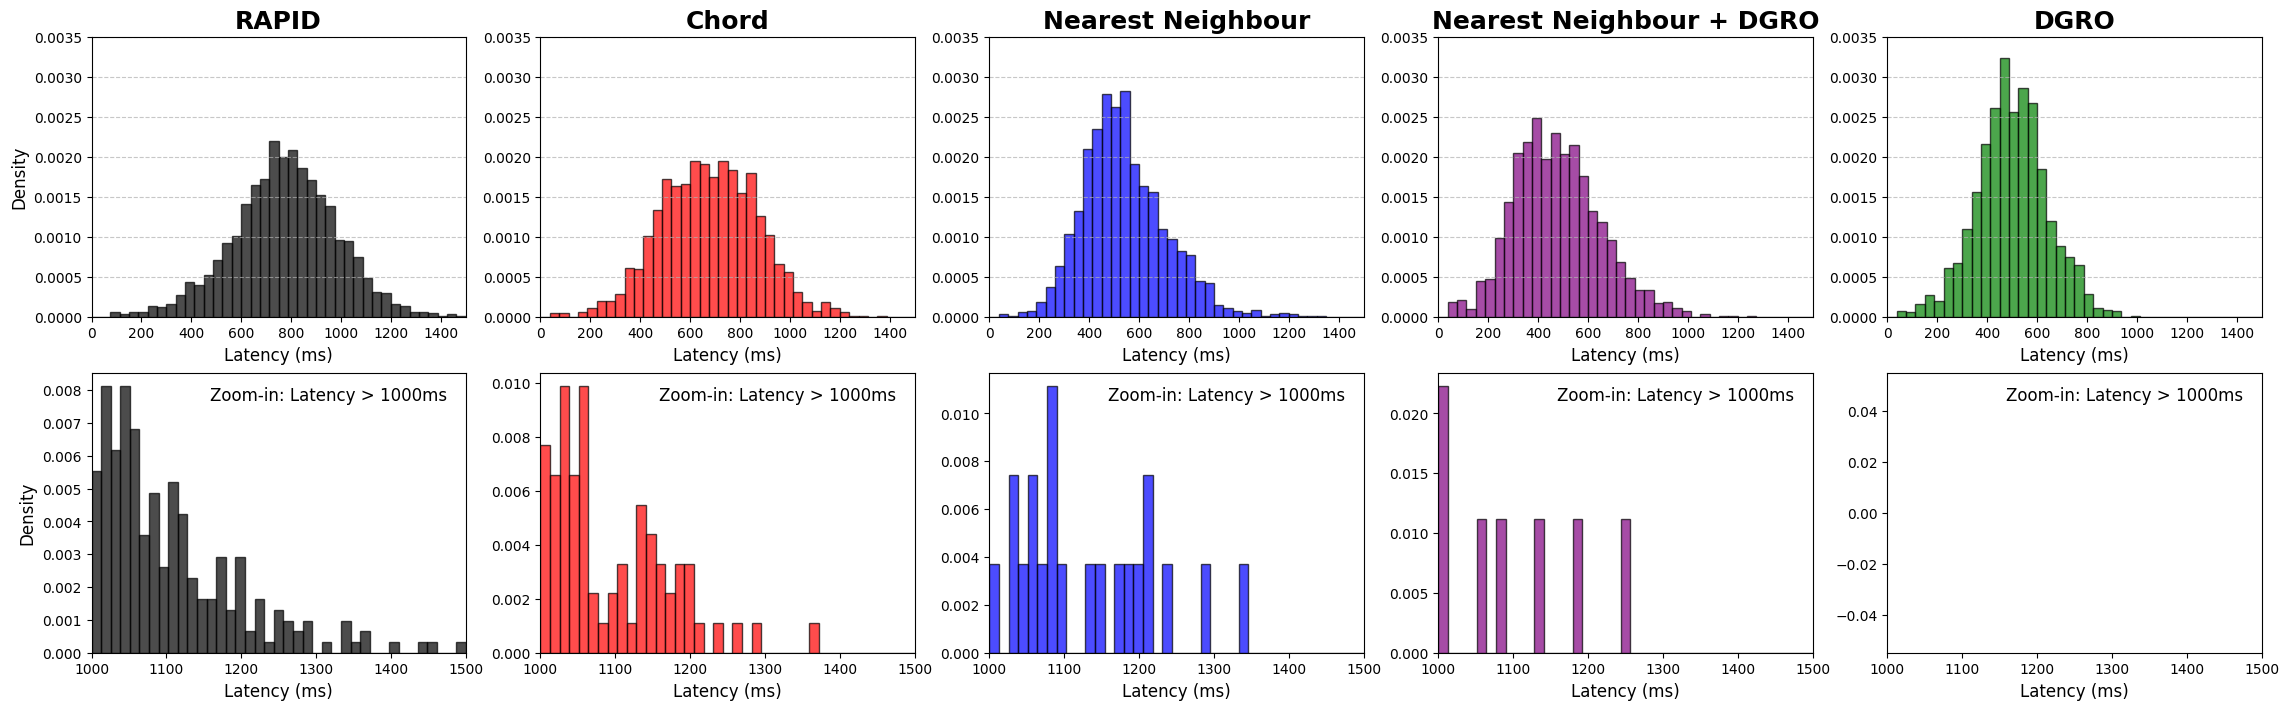

In [23]:
      

import matplotlib.pyplot as plt

# Plot the sorted list
# plt.rcParams['lines.linewidth'] = 2
# plt.rcParams["font.family"] = "Times New Roman"
# plt.rc('font', size=10, weight='bold')
# plt.rcParams["font.family"] = "Times New Roman"
# plt.rcParams["hatch.color"] = 'white'
# plt.rcParams['hatch.linewidth'] = 2.0
plt.rcdefaults()
labels = [
    'RAPID','Chord','Nearest Neighbour', 'Nearest Neighbour + DGRO','DGRO'

			  ]
fig, ax = plt.subplots(nrows=2, ncols=len(labels), figsize=(28, 8))
# 创建一个 2×5 的 subplot 结构
# fig = plt.figure(figsize=(28, 4))
# gs = gridspec.GridSpec(2, 1 + len(labels), figure=fig)  # 2 行 5 列

# 最左侧的图，占据两行
# ax0 = fig.add_subplot(gs[:, 0])  # `:` 表示合并第 0 列的两行

# # 其余 2x4 的图
# axes = []
# for row in range(2):
#     for col in range(1, 1 + len(labels)):  # 从第 1 列开始
#         ax = fig.add_subplot(gs[row, col])
#         axes.append(ax)
colors = ['k', 'r', 'b', 'purple', 'g']
linestyles = ['-', '--', '-.']
cnt = 0
# for k in [3, 5, 10]:
num_bins = 40
shared_bins = np.linspace(0, 1500, num_bins + 1)

for k in [8]:
	for i in range(len(filename)):
		# print(len(latencies[i]))
		path_latency_sorted = sorted(latencies[i])
		# print(path_latency_sorted[:5])
		print(labels[i], path_latency_sorted[-10:])
		# print(path_latency_sorted[:5], path_latency_sorted[-5:])x = [i / len(path_latency_sorted) for i in range(len(path_latency_sorted)]
		x = [j / len(path_latency_sorted) for j in range(len(path_latency_sorted))]
		# ax[0, i + 1].hist(path_latency_sorted, bins=shared_bins, color=colors[i],
		ax[0, i].hist(path_latency_sorted, bins=shared_bins, color=colors[i],
			  edgecolor='black', alpha=0.7, density=True,  label=labels[i],)
		high_latency = [l for l in path_latency_sorted if l >= 1000]  # 过滤大于 1000 的值
		bins_zoomed = np.linspace(1000, 1500, num_bins)  # 为右侧部分设置新的 bins
		# ax[1, i + 1].hist(high_latency, bins=bins_zoomed, alpha=0.7, edgecolor='black',color=colors[i])
		ax[1, i].hist(high_latency, bins=bins_zoomed, alpha=0.7, density=True,  edgecolor='black',color=colors[i])

ax[0, 0].set_ylabel("Density", fontsize=12)
ax[1, 0].set_ylabel("Density", fontsize=12)
for i in range(1, len(labels) + 1):
    # ax[0, i].set_xlabel("Latency (ms)")
    ax[0, i - 1].set_xlabel("Latency (ms)", fontsize=12)
    ax[1, i - 1].set_xlabel("Latency (ms)", fontsize=12)
    ax[0, i - 1].set_xlim([0, 1500])
    ax[0, i - 1].set_ylim([0, 0.0035])
    ax[0, i - 1].set_title(labels[i - 1], fontsize=18, weight='bold')
    ax[0, i - 1].grid(axis='y', linestyle='--', alpha=0.7)
    ax[1, i - 1].set_xlim([1000, 1500])
    ax[1, i - 1].text(
    0.95, 0.95,  # 位置（相对坐标，(1,1)是右上角）
    "Zoom-in: Latency > 1000ms", 
    transform=ax[1, i - 1].transAxes,  # 使用 Axes 坐标
    fontsize=12, 
    verticalalignment='top', 
    horizontalalignment='right',
)
# plt.show()
fig.savefig(f'N={N}_k={K}_histogram.pdf', bbox_inches='tight')